<a href="https://colab.research.google.com/github/Aayesha-86/AI-Manipulation-Bias-Analyzer/blob/main/AI_Manipulation_Detection_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip uninstall transformers accelerate peft -y
!pip install transformers==4.36.2
!pip install accelerate==0.25.0
!pip install torch

Found existing installation: transformers 4.36.2
Uninstalling transformers-4.36.2:
  Successfully uninstalled transformers-4.36.2
Found existing installation: accelerate 0.25.0
Uninstalling accelerate-0.25.0:
  Successfully uninstalled accelerate-0.25.0
  Using cached transformers-4.36.2-py3-none-any.whl.metadata (126 kB)
Using cached transformers-4.36.2-py3-none-any.whl (8.2 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.
  Using cached accelerate-0.25.0-py3-none-any.whl.metadata (18 kB)
Using cached accelerate-0.25.0-py3-none-any.whl (265 kB)


In [2]:
!pip install transformers
!pip install datasets
!pip install torch
!pip install scikit-learn

In [3]:
import pandas as pd
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import pandas as pd

df = pd.read_csv("/manipulation_bias_dataset_300.csv")

df.head()

,text,content_type,manipulation_label,bias_label,emotion
0,Doctors hate this simple health trick,Clickbait,1,2,Surprise
1,Unlock exclusive benefits with our membership,Advertisement,1,1,Surprise
2,Everyone is talking about this viral video today,Social Media,0,0,Anger
3,Doctors hate this simple health trick,Clickbait,1,2,Surprise
4,You won't believe what scientists just discovered,Clickbait,1,1,Surprise


In [6]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [7]:
texts = df["text"].tolist()
labels = df["manipulation_label"].tolist()

In [8]:
encodings = tokenizer(texts, truncation=True, padding=True)

In [9]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["manipulation_label"],
    test_size=0.2,
    random_state=42
)

In [10]:
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True)
test_encodings = tokenizer(list(test_texts), truncation=True, padding=True)

In [11]:
import torch

class ManipulationDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [12]:
train_dataset = ManipulationDataset(train_encodings, train_labels)
test_dataset = ManipulationDataset(test_encodings, test_labels)

In [13]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [14]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs"
)

In [15]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
)

trainer.train()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=60, training_loss=0.31020679473876955, metrics={'train_runtime': 894.2482, 'train_samples_per_second': 0.537, 'train_steps_per_second': 0.067, 'total_flos': 3453332601600.0, 'train_loss': 0.31020679473876955, 'epoch': 2.0})

In [16]:
import torch

def predict_manipulation(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = model(**inputs)

    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    manipulation_score = probs[0][1].item()

    if manipulation_score > 0.5:
        label = "Manipulative Content"
    else:
        label = "Neutral / Informational Content"

    print("Text:", text)
    print("Prediction:", label)
    print("Manipulation Score:", round(manipulation_score,3))

In [17]:
predict_manipulation(
"This shocking truth will change everything you believe about the economy"
)

Text: This shocking truth will change everything you believe about the economy
Prediction: Manipulative Content
Manipulation Score: 0.991


In [18]:
predict_manipulation(
"Government announces new public transportation policy for urban development"
)

Text: Government announces new public transportation policy for urban development
Prediction: Neutral / Informational Content
Manipulation Score: 0.011


In [19]:
predict_manipulation(
"You won't believe what happened after this celebrity posted a secret message"
)

Text: You won't believe what happened after this celebrity posted a secret message
Prediction: Manipulative Content
Manipulation Score: 0.987


In [20]:
!pip install matplotlib
!pip install gradio

In [21]:
from transformers import pipeline

emotion_analyzer = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [24]:
import matplotlib.pyplot as plt
from transformers import pipeline

emotion_analyzer = pipeline(
    "text-classification",
    model="j-hartmann/emotion-english-distilroberta-base",
    return_all_scores=True
)

def emotion_graph(text):

    results = emotion_analyzer(text)[0]

    labels = []
    scores = []

    for r in results:
        labels.append(r["label"])
        scores.append(r["score"])

    plt.figure()
    plt.bar(labels, scores)
    plt.title("Emotion Analysis")
    plt.ylabel("Confidence Score")
    plt.xlabel("Emotion")
    plt.xticks(rotation=45)
    plt.show()

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:105: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


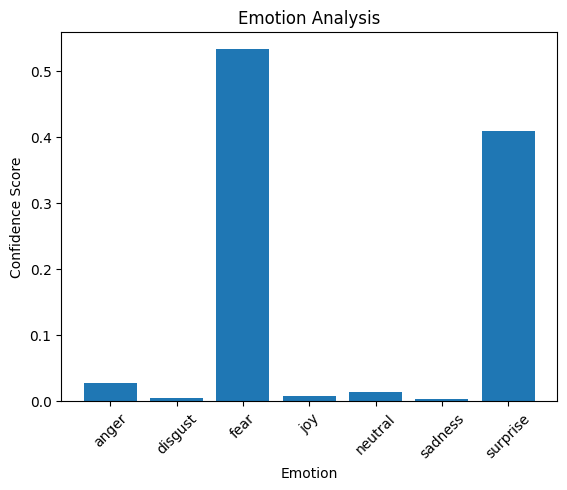

In [25]:
emotion_graph(
"This shocking truth will destroy everything you believed"
)

In [26]:
def bias_score(text):

    result = emotion_analyzer(text)[0]

    # find the highest emotion score
    max_score = 0
    max_emotion = ""

    for r in result:
        if r["score"] > max_score:
            max_score = r["score"]
            max_emotion = r["label"]

    if max_score > 0.7:
        bias = "High Bias"
    elif max_score > 0.4:
        bias = "Moderate Bias"
    else:
        bias = "Low Bias"

    print("Dominant Emotion:", max_emotion)
    print("Bias Level:", bias)
    print("Confidence:", round(max_score,2))

In [27]:
bias_score(
"This shocking secret will destroy everything you believed"
)

Dominant Emotion: fear
Bias Level: Moderate Bias
Confidence: 0.57


In [28]:
import re

trigger_words = [
"shocking",
"secret",
"truth",
"destroy",
"unbelievable",
"exclusive",
"breaking",
"you won't believe"
]

def highlight_manipulation(text):

    highlighted = text

    for word in trigger_words:
        highlighted = re.sub(
            word,
            f"[{word.upper()}]",
            highlighted,
            flags=re.IGNORECASE
        )

    print("Highlighted Text:")
    print(highlighted)

In [29]:
highlight_manipulation(
"This shocking secret will destroy everything you believed"
)

Highlighted Text:
This [SHOCKING] [SECRET] will [DESTROY] everything you believed


In [30]:
!pip install gradio

In [31]:
import torch

def full_analysis(text):

    # Manipulation prediction
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    outputs = model(**inputs)
    probs = torch.nn.functional.softmax(outputs.logits, dim=-1)

    manipulation_score = probs[0][1].item()

    # Emotion detection
    emotions = emotion_analyzer(text)[0]

    max_score = 0
    dominant_emotion = ""

    for e in emotions:
        if e["score"] > max_score:
            max_score = e["score"]
            dominant_emotion = e["label"]

    # Bias detection
    if max_score > 0.7:
        bias = "High Bias"
    elif max_score > 0.4:
        bias = "Moderate Bias"
    else:
        bias = "Low Bias"

    # Highlight trigger words
    import re

    trigger_words = [
        "shocking","secret","truth","destroy",
        "unbelievable","exclusive","breaking"
    ]

    highlighted = text

    for word in trigger_words:
        highlighted = re.sub(
            word,
            f"[{word.upper()}]",
            highlighted,
            flags=re.IGNORECASE
        )

    return (
        round(manipulation_score,2),
        dominant_emotion,
        bias,
        highlighted
    )

In [33]:
import gradio as gr

interface = gr.Interface(
    fn=full_analysis,
    inputs=gr.Textbox(lines=3, placeholder="Enter text to analyze..."),
    outputs=[
        gr.Number(label="Manipulation Score"),
        gr.Text(label="Dominant Emotion"),
        gr.Text(label="Bias Level"),
        gr.Textbox(label="Highlighted Manipulative Words")
    ],
    title="AI Manipulation & Bias Detection System",
    description="This AI system analyzes text for manipulation, emotional influence, and bias."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0494be0de05d6a2411.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
